In [32]:
#START - GETTING STARTED WITH EXPLORATION

# --- Core imports ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Always show plots inline
%matplotlib inline

# --- Path sanity check ---
print("Notebook running from:", Path.cwd())

# Define project paths
ROOT = Path("..").resolve()   # one level up from 'notebooks' → 'BBO'
DATA = ROOT / "data"

print("ROOT:", ROOT)
print("DATA:", DATA)

# List subfolders/files inside data
print("Contents of DATA:")
for p in sorted(DATA.iterdir()):
    print("   ", p.name)

Notebook running from: C:\Users\elena\Documents\BBO\notebooks
ROOT: C:\Users\elena\Documents\BBO
DATA: C:\Users\elena\Documents\BBO\data
Contents of DATA:
    F1
    F2
    F3
    F4
    F5
    F6
    F7
    F8
    function_summary.csv


In [33]:
#DATA LOADING SECTION
# --- Select which function to inspect ---
FN = "F6"   # change to F2..F8 as needed
print(f"Loading data for {FN}")

# --- Read function description ---
summary_path = DATA / "function_summary.csv"
func_info = pd.read_csv(summary_path)

if "Function" in func_info.columns and "Description" in func_info.columns:
    desc_row = func_info.loc[func_info["Function"] == FN, "Description"]
    if not desc_row.empty:
        print(f"\n{FN} description:\n{desc_row.values[0]}")
    else:
        print(f"No description found for {FN} in function_summary.csv.")
else:
    print("⚠️ function_summary.csv missing expected columns.")

# --- Load inputs/outputs ---
X_path = DATA / FN / "initial_inputs.npy"
y_path = DATA / FN / "initial_outputs.npy"

X = np.load(X_path)
y = np.load(y_path)

# --- Build DataFrame for exploration ---
cols = [f"x{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=cols)
df["y"] = y

# --- Show quick look ---
display(df.head())
display(df.describe())

# --- Summary dictionary ---
summary = {
    "rows": len(df),
    "dims": X.shape[1],
    "bounds": {c: (float(df[c].min()), float(df[c].max())) for c in cols},
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
}
print("\nSummary of loaded data:")
summary


Loading data for F6

F6 description:
You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237


,x1,x2,x3,x4,x5,y
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,0.541269,0.546911,0.480124,0.555746,0.403997,-1.447796
std,0.296839,0.285597,0.312949,0.290098,0.303480,0.499169
min,0.021735,0.114404,0.016523,0.045613,0.004911,-2.571170
25%,0.258906,0.291470,0.187288,0.356552,0.110624,-1.702558
50%,0.618812,0.536336,0.443284,0.648324,0.501953,-1.356682
75%,0.770620,0.803484,0.732552,0.726272,0.614962,-1.209955
max,0.957740,0.931871,0.978806,0.982008,0.892819,-0.495915



Summary of loaded data:


{'rows': 21,
 'dims': 5,
 'bounds': {'x1': (0.021735307663796388, 0.9577396688833609),
  'x2': (0.11440374416322774, 0.9318712161635005),
  'x3': (0.01652289968556364, 0.9788057635601997),
  'x4': (0.045613185779449616, 0.982008),
  'x5': (0.004911495864404647, 0.892819191058788)},
 'y_min': -2.5711696316081234,
 'y_max': -0.49591501506217267}

In [34]:
# --- save summary info + notes + timestamp to spreadsheet ---
sdf = pd.read_csv(DATA / "function_summary.csv")
note = f"Exploration: {summary['dims']}D, {summary['rows']} pts. y∈[{summary['y_min']:.6g},{summary['y_max']:.3g}]"
now  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

sdf.loc[sdf["Function"] == FN,
        ["Rows","Dims","Bounds","y_min","y_max","Best_y_so_far","Notes","Last_updated"]] = [
    summary["rows"], summary["dims"], str(summary["bounds"]),
    summary["y_min"], summary["y_max"], summary["y_max"], note, now
]

sdf.to_csv(DATA / "function_summary.csv", index=False)


F6 has 5 input dimensions


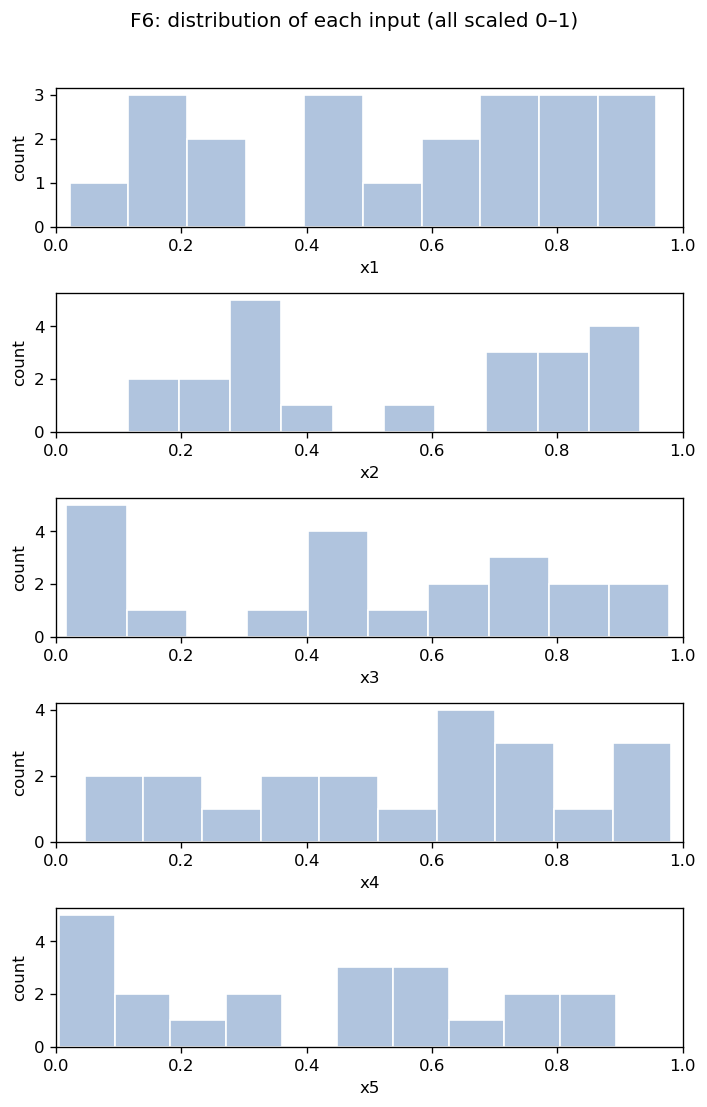

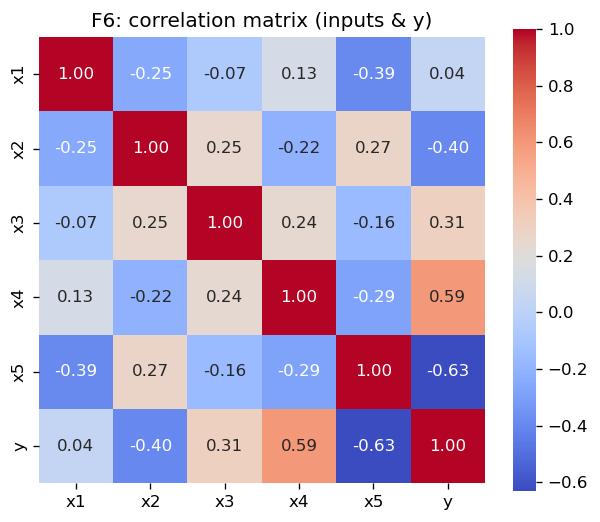

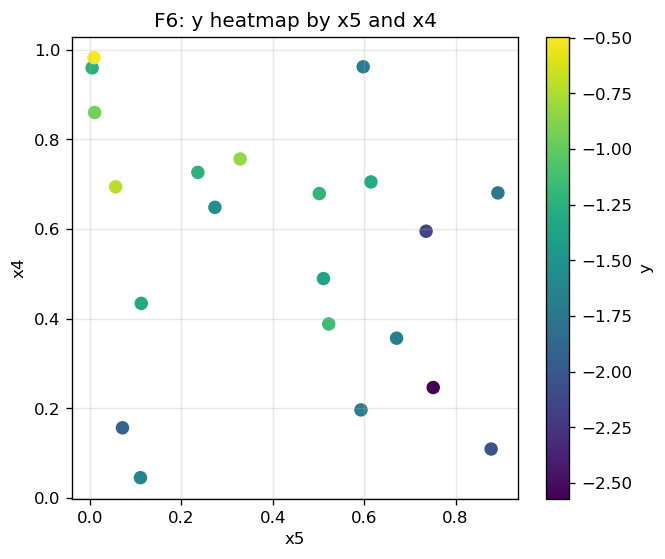

In [35]:
#INITIAL PLOTS TO VISUALISE THE DATA

# --- Quick visual exploration of inputs and outputs ---
import seaborn as sns

xs = [c for c in df.columns if c.startswith("x")]
d = len(xs)

print(f"{FN} has {d} input dimensions")

if d == 1:
    plt.scatter(df[xs[0]], df["y"], s=30, color="steelblue")
    plt.xlabel(xs[0]); plt.ylabel("y")
    plt.title(f"{FN}: y vs {xs[0]}")
    plt.grid(True, alpha=0.3)
    plt.show()

elif d == 2:
    sc = plt.scatter(df[xs[0]], df[xs[1]], c=df["y"], cmap="viridis", s=40)
    plt.xlabel(xs[0]); plt.ylabel(xs[1])
    plt.title(f"{FN}: inputs coloured by y (higher = better)")
    plt.colorbar(sc, label="y")
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    # --- 1D distributions per input ---
    fig, axs = plt.subplots(d, 1, figsize=(6, 1.8*d), dpi=120)
    for i, c in enumerate(xs):
        axs[i].hist(df[c], bins=10, color="lightsteelblue", edgecolor="white")
        axs[i].set_xlabel(c); axs[i].set_ylabel("count")
        axs[i].set_xlim(0,1)
    fig.suptitle(f"{FN}: distribution of each input (all scaled 0–1)", y=1.02)
    plt.tight_layout()
    plt.show()

    # --- correlation matrix (inputs + y) ---
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(6,5), dpi=120)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title(f"{FN}: correlation matrix (inputs & y)")
    plt.show()

    # --- top 2D coloured scatter using most correlated vars with y ---
    corr_y = corr["y"].abs().sort_values(ascending=False)
    top2 = corr_y.index[1:3]  # skip 'y' itself
    if len(top2) == 2:
        plt.figure(figsize=(6,5), dpi=120)
        sc = plt.scatter(df[top2[0]], df[top2[1]], c=df["y"], cmap="viridis", s=50)
        plt.xlabel(top2[0]); plt.ylabel(top2[1])
        plt.title(f"{FN}: y heatmap by {top2[0]} and {top2[1]}")
        plt.colorbar(sc, label="y")
        plt.grid(True, alpha=0.3)
        plt.show()


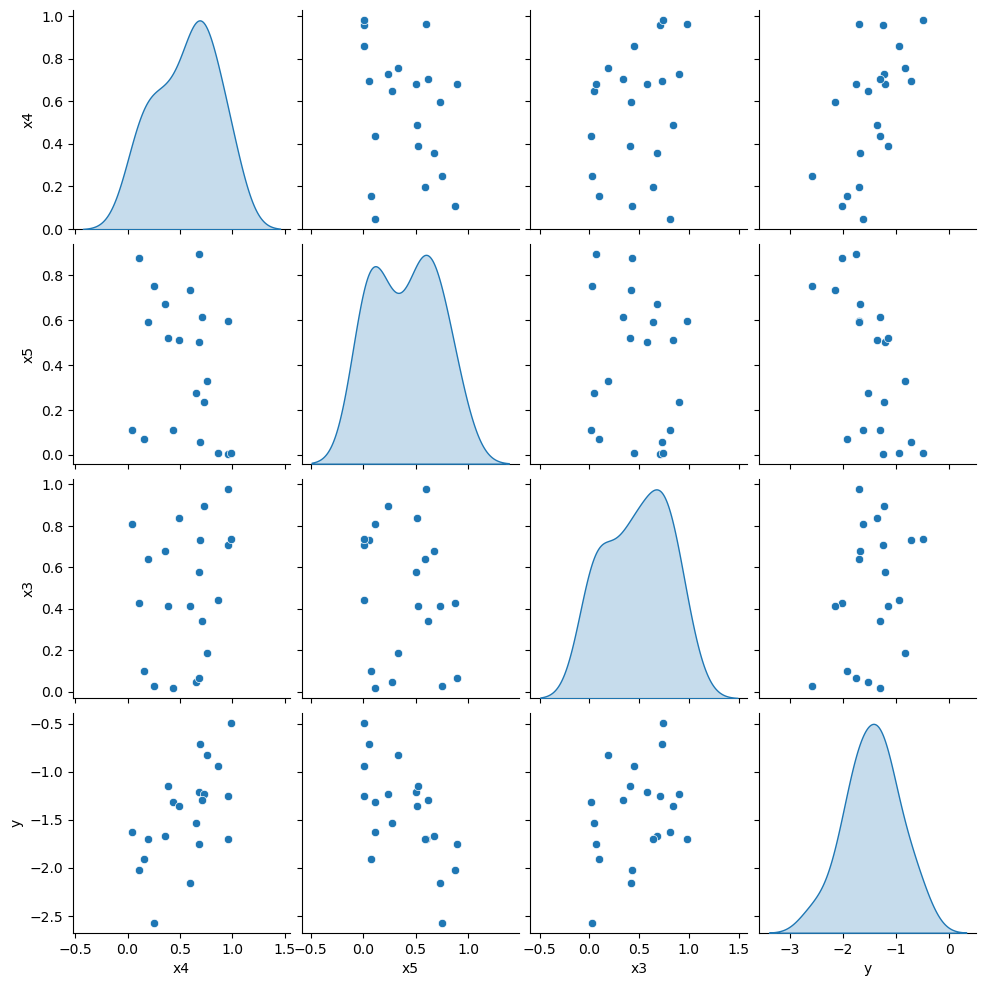

In [36]:
# --- pairwise relationships between key variables and y ---
g = sns.pairplot(df, vars=["x4", "x5", "x3", "y"], diag_kind="kde")
plt.show()

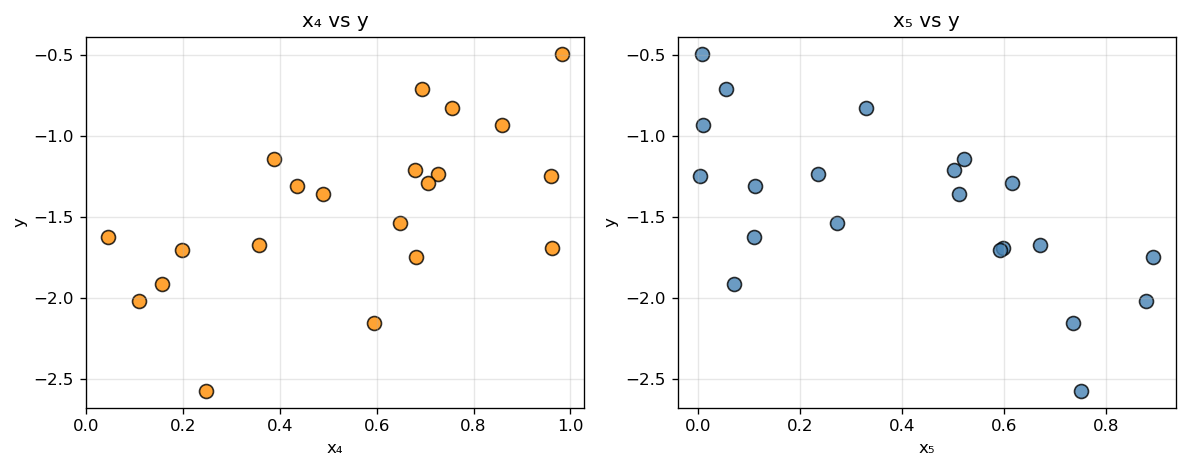

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

axes[0].scatter(df["x4"], y, color="darkorange", edgecolor="k", s=70, alpha=0.8)
axes[0].set_title("x₄ vs y")
axes[0].set_xlabel("x₄")
axes[0].set_ylabel("y")
axes[0].grid(alpha=0.3)

axes[1].scatter(df["x5"], y, color="steelblue", edgecolor="k", s=70, alpha=0.8)
axes[1].set_title("x₅ vs y")
axes[1].set_xlabel("x₅")
axes[1].set_ylabel("y")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# # use this if you only need to explore specific features
# X = df[["x1", "x2", "x3", "x4"]]
# y = df["y"]

# Automatically detect all input columns (everything except 'y')
Xcols = [col for col in df.columns if col != "y"]
X = df[Xcols]
y = df["y"]

print("Inputs:", list(X.columns), "| X shape:", X.shape, "| y shape:", y.shape)

Inputs: ['x1', 'x2', 'x3', 'x4', 'x5'] | X shape: (21, 5) | y shape: (21,)


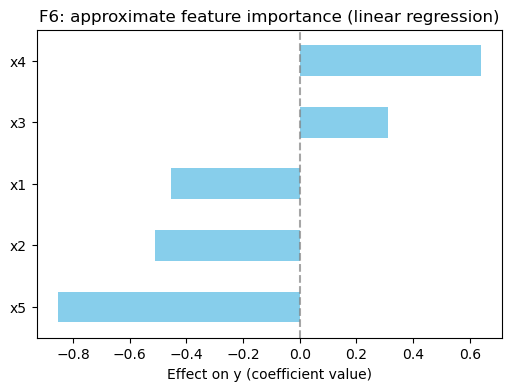

Feature coefficients (sorted):


,Coefficient
x4,0.638564
x3,0.311513
x1,-0.453071
x2,-0.510458
x5,-0.853301


In [39]:
from sklearn.linear_model import LinearRegression

# Fit linear model
model = LinearRegression().fit(X, y)

# Determine column names safely
if hasattr(X, "columns"):
    feature_names = X.columns
else:
    feature_names = [f"x{i+1}" for i in range(X.shape[1])]

# Get coefficients as a Series
importance = pd.Series(model.coef_.ravel(), index=feature_names)

# Visualize
plt.figure(figsize=(6, 4))
importance.sort_values().plot(kind="barh", color="skyblue")
plt.title(f"{FN}: approximate feature importance (linear regression)")
plt.xlabel("Effect on y (coefficient value)")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.show()

# Print results neatly
print("Feature coefficients (sorted):")
display(importance.sort_values(ascending=False).to_frame("Coefficient"))


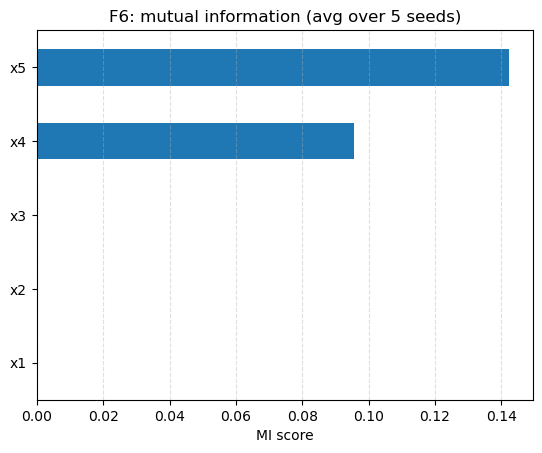

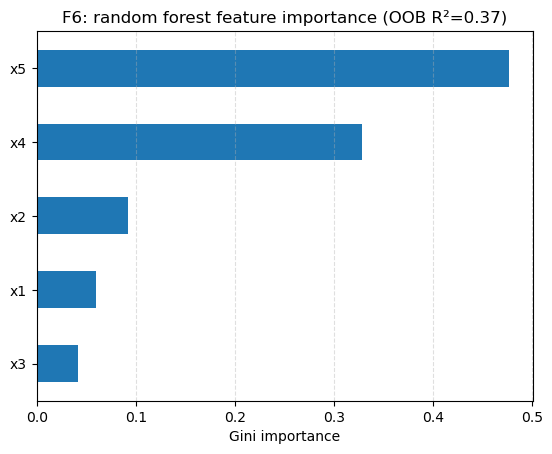

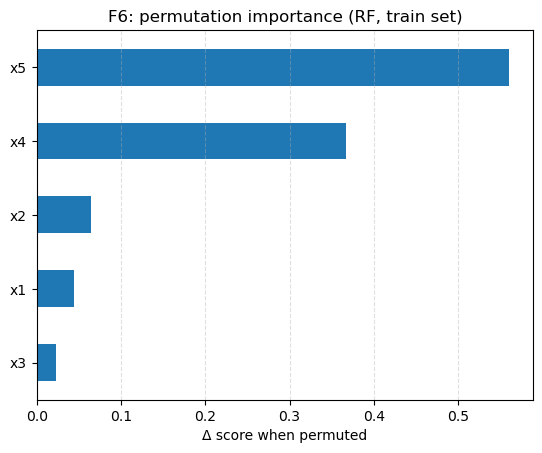

In [40]:
#NON LINEAR IMPORTANCE

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# X, y from your DataFrame
X = df[Xcols]
y = df["y"]

# --- 1) Mutual Information (average across seeds to reduce variance) ---
seeds = [0, 1, 2, 3, 4]
mi_runs = []
for s in seeds:
    mi_runs.append(mutual_info_regression(X, y, random_state=s, n_neighbors=3))
mi = np.mean(mi_runs, axis=0)

pd.Series(mi, index=Xcols).sort_values().plot(kind="barh")
plt.title(f"{FN}: mutual information (avg over {len(seeds)} seeds)")
plt.xlabel("MI score")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

# --- 2) Random Forest importance (slight regularization + OOB sanity) ---
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,   # a touch of regularization for n≈21
    oob_score=True,
    bootstrap=True,
    random_state=0,
)
rf.fit(X, y)
pd.Series(rf.feature_importances_, index=Xcols).sort_values().plot(kind="barh")
plt.title(f"{FN}: random forest feature importance (OOB R²={getattr(rf, 'oob_score_', np.nan):.2f})")
plt.xlabel("Gini importance")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

# --- 3) Permutation importance on the fitted RF (model-agnostic) ---
perm = permutation_importance(rf, X, y, n_repeats=200, random_state=0)
pd.Series(perm.importances_mean, index=Xcols).sort_values().plot(kind="barh")
plt.title(f"{FN}: permutation importance (RF, train set)")
plt.xlabel("Δ score when permuted")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

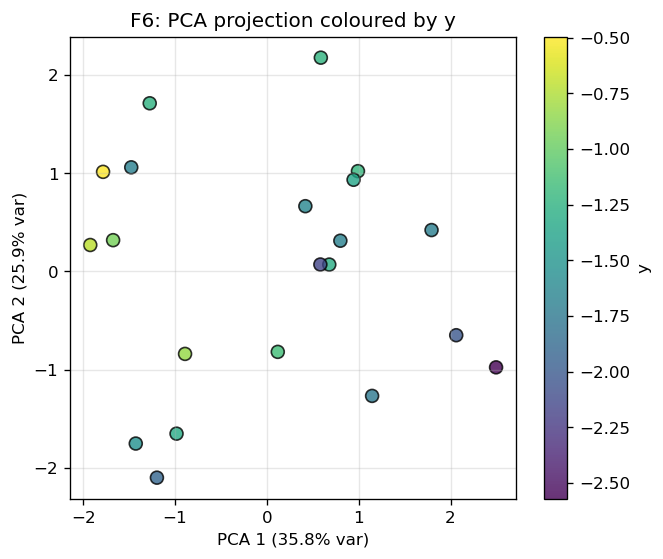

Explained variance ratio: [0.358 0.259]
Total variance explained by first 2 PCs: 61.7%


In [41]:
#PCA PROJECTION FOR INTUITION
#Reduce the 5D into 2 principal components 
#that capture the main variance in your data
#and colour the points by y to spot trends or clusters.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# --- Standardise inputs (always important before PCA) ---
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# --- Run PCA ---
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

# --- Plot ---
plt.figure(figsize=(6, 5), dpi=120)
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=60, edgecolor="k", alpha=0.8)
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title(f"{FN}: PCA projection coloured by y")
plt.colorbar(sc, label="y")
plt.grid(True, alpha=0.3)
plt.show()

# --- Explained variance info ---
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print(f"Total variance explained by first 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [42]:
# --- Show component loadings (how much each original feature contributes to each PC) ---
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PCA1", "PCA2"]
).T  # transpose so features are rows

display(loadings.style.background_gradient(cmap="coolwarm", axis=None).format("{:+.2f}"))

,PCA1,PCA2
x1,-0.50,-0.19
x2,+0.46,+0.43
x3,-0.06,+0.79
x4,-0.44,+0.37
x5,+0.58,-0.14


Best point (highest y):


,x1,x2,x3,x4,x5,y
20,0.4113,0.2337,0.7383,0.982,0.009,-0.4959


Nearest neighbours to best point:


,x1,x2,x3,x4,x5,y,dist_from_best
20,0.4113,0.2337,0.7383,0.9820,0.0090,-0.4959,0.0000
0,0.7282,0.1547,0.7326,0.6940,0.0564,-0.7143,0.4380
17,0.7829,0.5363,0.4433,0.8597,0.0103,-0.9358,0.5758
4,0.6188,0.3318,0.1873,0.7562,0.3288,-0.8292,0.7138
5,0.7850,0.9107,0.7081,0.9592,0.0049,-1.2470,0.7741


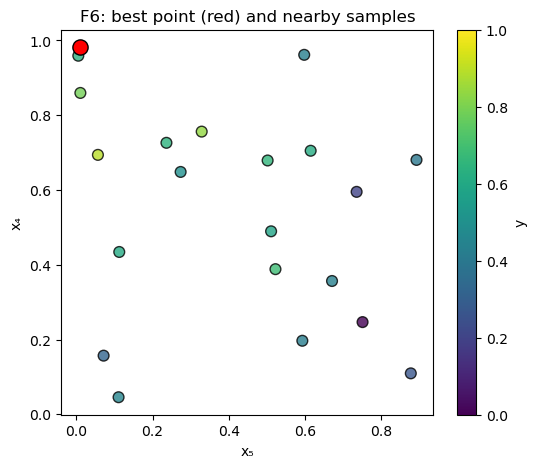

In [43]:
#BEST POINT + NEIGHBORHOOD

# Find best-performing point (highest y)
best_idx = df["y"].idxmax()
best_row = df.loc[best_idx]
print("Best point (highest y):")
display(best_row.to_frame().T.round(4))

# Recompute clean X columns (exclude helper columns if already exist)
Xcols = [c for c in df.columns if c not in ["y", "dist_from_best"]]

# Compute Euclidean distance from each point to the best point
df["dist_from_best"] = ((df[Xcols] - best_row[Xcols])**2).sum(axis=1)**0.5

# Show the closest 5 points (including the best one)
neighbors = df.nsmallest(5, "dist_from_best")
print("Nearest neighbours to best point:")
display(neighbors[Xcols + ["y", "dist_from_best"]].round(4))

# Optional: simple visual check (2D projection using x4 and x5)
plt.figure(figsize=(6,5))
plt.scatter(df["x5"], df["x4"], c=df["y"], cmap="viridis", s=60, edgecolor="k", alpha=0.8)
plt.scatter(best_row["x5"], best_row["x4"], c="red", s=120, edgecolor="k", label="Best point")
plt.xlabel("x₅"); plt.ylabel("x₄")
plt.title(f"{FN}: best point (red) and nearby samples")
plt.colorbar(label="y")
#plt.legend()
plt.show()


Surrogate RF fitted. CV R^2 ≈ 0.37 | OOB R^2 ≈ 0.42


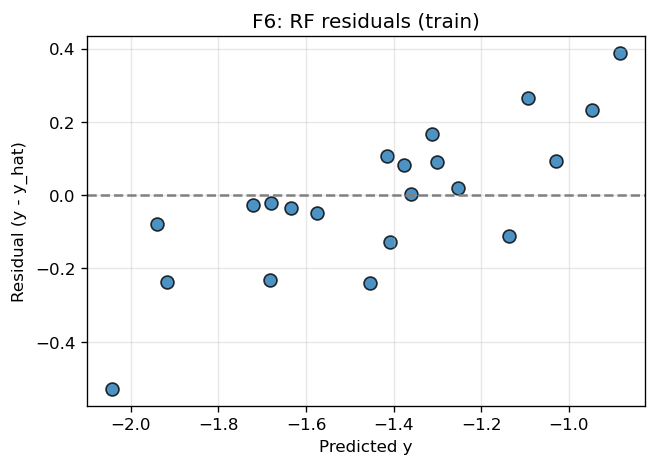

In [44]:
# FIT A SURROGATE
from sklearn.model_selection import KFold, cross_val_score

# --- robust, low-tuning surrogate ---
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    max_features="sqrt",   # robust default
    min_samples_leaf=2,    # gentle regularization for n≈21
    bootstrap=True,
    oob_score=True,        # extra generalization check
    random_state=0,
    n_jobs=-1,
)
rf.fit(X, y)

# ---- CV (shuffle for stability on tiny datasets) ----
cv = min(5, len(df))
kf = KFold(n_splits=cv, shuffle=True, random_state=0)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring="r2").mean()

print(f"Surrogate RF fitted. CV R^2 ≈ {cv_r2:.2f} | OOB R^2 ≈ {getattr(rf, 'oob_score_', np.nan):.2f}")

# ---- quick residual check ----
y_hat = rf.predict(X)
resid = y - y_hat
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(y_hat, resid, s=60, edgecolor="k", alpha=0.8)
plt.axhline(0, color="gray", ls="--")
plt.xlabel("Predicted y")
plt.ylabel("Residual (y - y_hat)")
plt.title(f"{FN}: RF residuals (train)")
plt.grid(alpha=0.3)
plt.show()

In [52]:
# CANDIDATE GENERATION
# === CANDIDATE GENERATION (global + local) and SCORING (RF + EI) ===
import numpy as np
from scipy.stats import norm

# 0) Domain bounds — prefer portal bounds (do NOT fall back to observed)
d = len(Xcols)
portal_bounds = np.array([[0.0, 1.0]] * d)  # <-- replace if your portal bounds differ
lo, hi = portal_bounds[:,0].copy(), portal_bounds[:,1].copy()

# (Optional: KEEP THESE ONLY FOR REPORTING, NOT FOR SCALING)
# obs_lo = df[Xcols].min().to_numpy(float)
# obs_hi = df[Xcols].max().to_numpy(float)
# NOTE: Do not overwrite lo/hi with observed min/max for candidate scaling.

# Fallback to observed if any bound is degenerate (shouldn't happen here)
obs_lo = df[Xcols].min().to_numpy(float)
obs_hi = df[Xcols].max().to_numpy(float)
deg = (hi - lo) < 1e-12
lo = np.where(deg, obs_lo, lo)
hi = np.where(deg, obs_hi, hi)

def sample_lhs(n, d, rng):
    cut = np.linspace(0, 1, n+1)
    u = rng.uniform(size=(n, d))
    a, b = cut[:-1][:,None], cut[1:][:,None]
    X = a + (b-a)*u
    for j in range(d):
        rng.shuffle(X[:, j])
    return X

rng = np.random.default_rng(42)
N_GLOBAL = 6000
N_LOCAL  = 4000
trust_region_frac = 0.15   # 15% of range in unit space

# 1) Global candidates in [0,1]^d via LHS
C_global_u = sample_lhs(N_GLOBAL, d, rng)

# 2) Local candidates around the incumbent (in unit space)
best_idx = df["y"].idxmax()
x_best   = df.loc[best_idx, Xcols].to_numpy(float)
x_best_u = (x_best - lo) / (hi - lo + 1e-12)
C_local_u = np.clip(
    x_best_u + rng.normal(scale=trust_region_frac, size=(N_LOCAL, d)),
    0, 1
)

# Merge and scale back to original domain
C_u = np.vstack([C_global_u, C_local_u])
C   = lo + C_u * (hi - lo)

# --- Sanity check: candidate coverage ---
print("cand shape:", C.shape)
print("feature columns:", Xcols)

mins = C.min(axis=0)
maxs = C.max(axis=0)
for c, lo_i, hi_i, mn, mx in zip(Xcols, lo, hi, mins, maxs):
    print(f"{c}: bounds [{lo_i:.3f}, {hi_i:.3f}]  |  cand range [{mn:.3f}, {mx:.3f}]")

# 3) Score candidates with RF mean + uncertainty from trees
#    (tree-wise predictions -> mean & std)
tree_preds = np.stack([est.predict(C) for est in rf.estimators_], axis=0)  # (n_trees, n_cand)
mu  = tree_preds.mean(axis=0)
sd  = tree_preds.std(axis=0, ddof=1)

# 4) Acquisition: Expected Improvement (maximize)
y_best = df["y"].max()
xi = 0.02  # exploration knob
sd_safe = np.maximum(sd, 1e-12)
imp = mu - y_best - xi
Z = imp / sd_safe
EI = imp * norm.cdf(Z) + sd_safe * norm.pdf(Z)

# 5) (Optional) minimum distance filter so we don't resample too close to existing points
Xu = (df[Xcols].to_numpy(float) - lo) / (hi - lo + 1e-12)
min_dist = 0.02
def too_close(z, Z, thr=min_dist):
    diff = Z - z
    return np.any(np.sqrt((diff*diff).sum(axis=1)) < thr)

order = np.argsort(-EI)
pick_u = None

# --- Prevent exact duplicates + near duplicates ---
# Create a set of tuples representing existing points rounded to 6 decimals
existing = set(tuple(np.round(x, 6)) for x in Xu)

for idx in order:
    cand_u = C_u[idx]
    tup = tuple(np.round(cand_u, 6))
    # Skip if identical to an existing point OR too close in space
    if tup not in existing and not too_close(cand_u, Xu, thr=min_dist):
        pick_u = cand_u
        pick_idx = idx
        break

# Fallback if all candidates are too close
if pick_u is None:
    pick_u = C_u[order[0]]
    pick_idx = order[0]

x_next = lo + pick_u * (hi - lo)

print(f"{FN} — candidate selection")
print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI (xi={xi}): predicted mean={mu[pick_idx]:.4f}, std={sd[pick_idx]:.4f}, EI={EI[pick_idx]:.4f}")
print("x_next:", np.round(x_next, 6))

cand shape: (10000, 5)
feature columns: ['x1', 'x2', 'x3', 'x4', 'x5']
x1: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x2: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x3: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x4: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x5: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
F6 — candidate selection
Best y so far: -0.495915
Chosen by EI (xi=0.02): predicted mean=-1.0732, std=0.4189, EI=0.0145
x_next: [0.912705 0.009364 0.747648 0.995287 0.062908]


In [53]:
#EI BLOCK (Expected Improvements)

# Build a proposals table from existing arrays (C, mu, sd, EI)
cand_df = pd.DataFrame(C, columns=Xcols)
cand_df["y_pred"] = mu
cand_df["y_std"]  = sd
cand_df["EI"]     = EI

# Show top-5 by mean (exploit) and by EI (explore-aware)
display(cand_df.nlargest(5, "y_pred").round(6))
display(cand_df.nlargest(5, "EI").round(6))


,x1,x2,x3,x4,x5,y_pred,y_std,EI
8801,0.537699,0.000000,0.726519,0.869852,0.000000,-0.870183,0.257123,0.006980
6660,0.545238,0.000000,0.721203,0.893362,0.012588,-0.870968,0.257161,0.006936
8674,0.573687,0.202176,0.747338,0.882668,0.000000,-0.871420,0.259468,0.007193
6853,0.583466,0.114548,0.733232,0.743507,0.000000,-0.871567,0.261929,0.007494
6651,0.580333,0.000000,0.736655,1.000000,0.000000,-0.871690,0.261169,0.007389


,x1,x2,x3,x4,x5,y_pred,y_std,EI
740,0.912705,0.009364,0.747648,0.995287,0.062908,-1.073187,0.418870,0.014504
7267,0.868444,0.173670,0.866058,0.904849,0.000000,-1.059391,0.410044,0.014291
5259,0.984539,0.151781,0.973856,0.896244,0.027919,-1.059105,0.409834,0.014283
8425,0.875102,0.175895,0.871028,0.893641,0.000000,-1.059274,0.409919,0.014282
6085,0.108357,0.153164,0.754516,0.946619,0.000000,-0.925848,0.337192,0.014264


In [54]:
# === FINAL OUTPUT: RECOMMENDED NEXT POINT TO SUBMIT ===
print("\n" + "="*70)
print(f"{FN} — RECOMMENDED NEXT POINT")
print("="*70)

print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI (xi={xi}): predicted mean={mu[pick_idx]:.4f}, "
      f"std={sd[pick_idx]:.4f}, EI={EI[pick_idx]:.4f}")
print(f"Min distance from existing points: {too_close(pick_u, Xu, thr=min_dist):.3f}")

# Present x_next neatly
x_next_df = pd.DataFrame([x_next], columns=Xcols).round(6)
display(x_next_df.style.set_caption("🚀 Recommended query to submit this week"))

print("="*70)
print("Copy these values into the Capstone submission portal for this week's query.")
print("="*70)



F6 — RECOMMENDED NEXT POINT
Best y so far: -0.495915
Chosen by EI (xi=0.02): predicted mean=-1.0732, std=0.4189, EI=0.0145
Min distance from existing points: 0.000


,x1,x2,x3,x4,x5
0,0.912705,0.009364,0.747648,0.995287,0.062908


Copy these values into the Capstone submission portal for this week's query.


IF YOU WANT TO AUTOMATE KEEPING THE RESULT IN A FILE

# --- Persist the chosen point for weekly tracking ---
log_row = pd.DataFrame([x_next], columns=Xcols).round(6)
log_row["y_best_so_far"] = float(y_best)
log_row["pred_mean"]     = float(mu[pick_idx])
log_row["pred_std"]      = float(sd[pick_idx])
log_row["EI"]            = float(EI[pick_idx])
log_row["timestamp"]     = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

save_path = DATA / FN / "proposed_next.csv"

# Append if file exists, else create
if save_path.exists():
    prev = pd.read_csv(save_path)
    out  = pd.concat([prev, log_row], ignore_index=True)
else:
    out = log_row

out.to_csv(save_path, index=False)
print("✅ Saved proposal log to:", save_path)
display(out.tail(3))  # show the last few entries
